# Kernel Regression

The aim of this notebook is to fit a non-parametric line onto the sunspots data.

In [2]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.kernel_regression import KernelReg

In [3]:
# importing the dataset
sunspots = pd.read_csv('sunspot_data_processed.csv')
sunspots.head()

,Date (month),Year,Month,Date in fraction of year,Monthly mean total sunspot number,Monthly mean,Number of observations,Definitive or provisional value
0,1749-01-01,1749,1,1749.042,96.7,-1.0,-1,1
1,1749-04-01,1749,4,1749.288,92.8,-1.0,-1,1
2,1749-05-01,1749,5,1749.371,141.7,-1.0,-1,1
3,1749-12-01,1749,12,1749.958,142.0,-1.0,-1,1
4,1750-02-01,1750,2,1750.123,126.5,-1.0,-1,1


Ordering

In [4]:
sunspots.drop(columns=['Monthly mean', 'Number of observations', 'Definitive or provisional value'], inplace=True)
# ordering by date
sunspots.sort_values(by='Date in fraction of year', inplace=True)
sunspots.head()

,Date (month),Year,Month,Date in fraction of year,Monthly mean total sunspot number
0,1749-01-01,1749,1,1749.042,96.7
2205,1749-02-01,1749,2,1749.123,104.3
2206,1749-03-01,1749,3,1749.204,116.7
1,1749-04-01,1749,4,1749.288,92.8
2,1749-05-01,1749,5,1749.371,141.7


We will assign x as the date in fraction of year, and y as the monthly mean total sunspot number

In [5]:
x = sunspots['Date in fraction of year'].values
y = sunspots['Monthly mean total sunspot number'].values

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print(x.shape, y.shape)

(3304, 1) (3304, 1)


Plotting a scatterplot

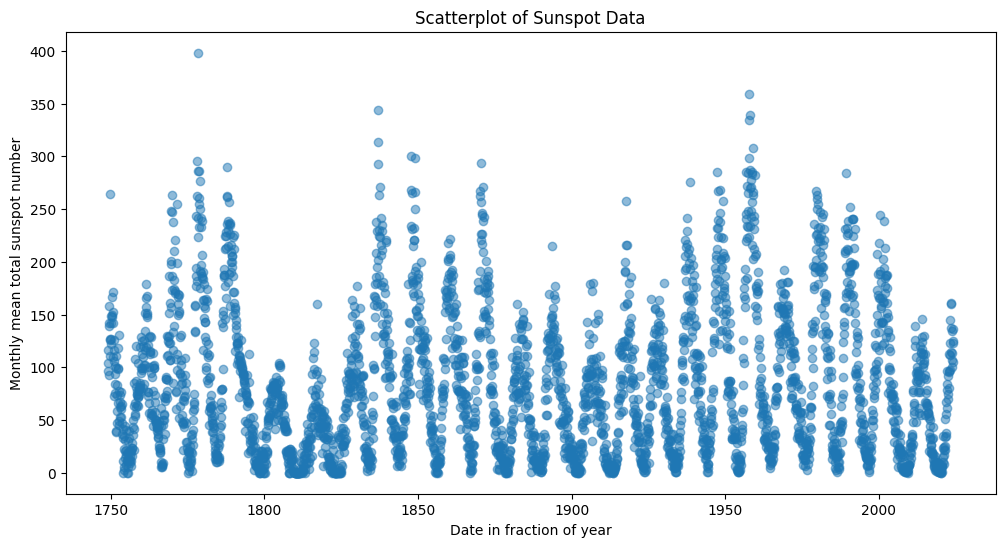

In [6]:
plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.5)
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Scatterplot of Sunspot Data')
plt.show()

### Regression

In [7]:
kr = KernelReg(endog=y, exog=x, var_type='c')
print(kr)

KernelReg instance
Number of variables: k_vars = 1
Number of samples:   N = 3304
Variable types:      c
BW selection method: cv_ls
Estimator type: ll



In [8]:
mean, mfx = kr.fit()
print(len(mean))
print(len(mfx))

3304
3304


In [9]:
# What is the bandwidth used?
print(kr.bw)

[0.09189124]


In [10]:
# What is R2 value?
print(kr.r_squared())

0.9583139603053892


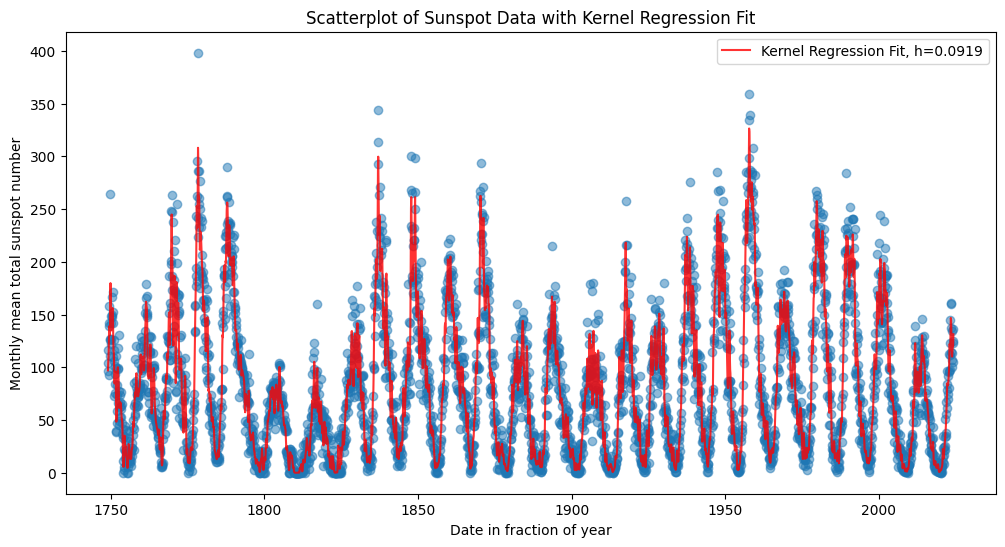

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, mean, color='red', alpha=0.8, label='Kernel Regression Fit, h={:.4f}'.format(kr.bw[0]))
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Scatterplot of Sunspot Data with Kernel Regression Fit')
plt.legend()
plt.show()

#### Changing the bandwidths to see what happens manually

In [12]:
h_values = [0.05, 0.1, 1, 5, 10, 20, 50]
means = []

for h in h_values:
    kr_temp = KernelReg(endog=y, exog=x, var_type='c', bw=[h])
    mean_temp, _ = kr_temp.fit()
    means.append(mean_temp)

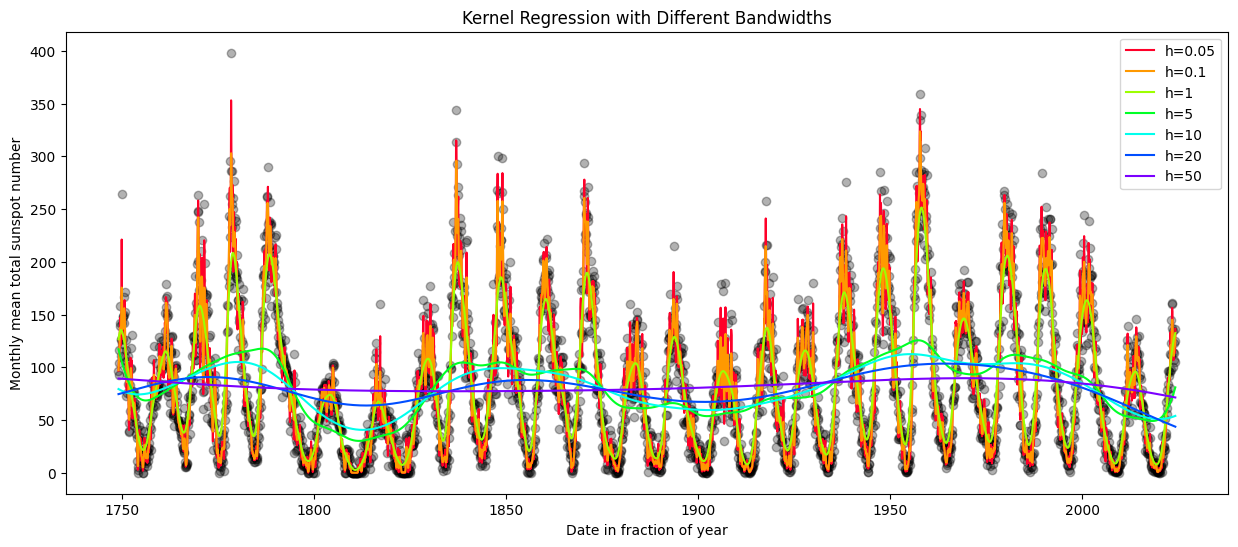

In [13]:
plt.figure(figsize=(15, 6))
plt.scatter(x, y, alpha=0.3, color='black')
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Kernel Regression with Different Bandwidths')
for i, h in enumerate(h_values):
    # plt.plot(x, means[i], label='h={}'.format(h), alpha=0.8, color=plt.cm.magma_r(i / len(h_values)))
    # Using a different colormap for better visibility
    plt.plot(x, means[i], label='h={}'.format(h), alpha=1, color=plt.cm.gist_rainbow(i / len(h_values)))
plt.legend()
plt.show()

In case the graph above is too busy, a simplified graph has been provided below

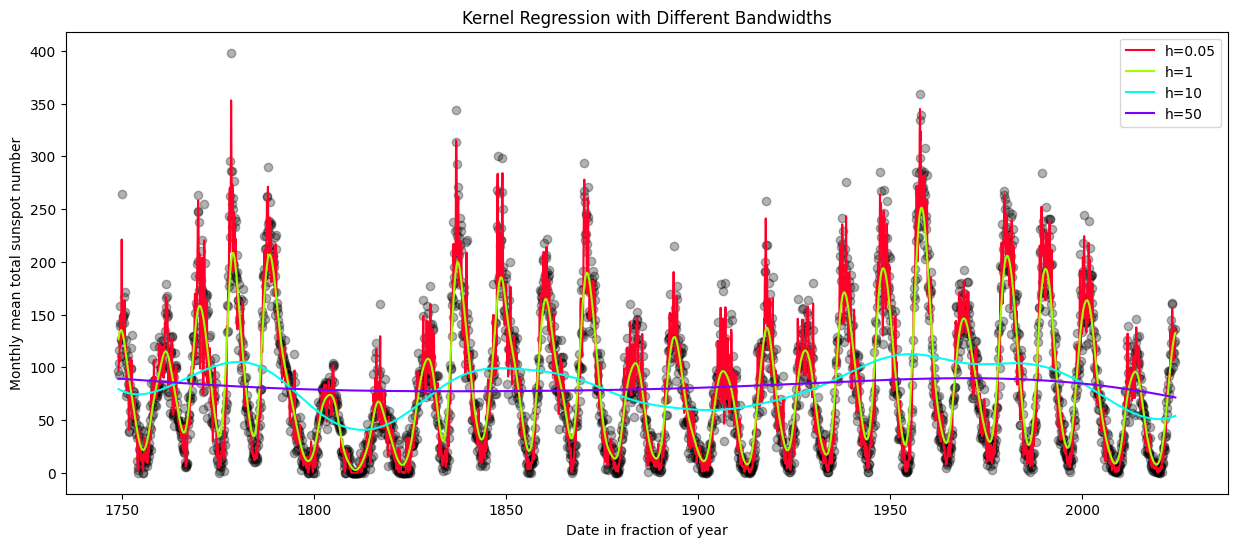

In [42]:
plt.figure(figsize=(15, 6))
plt.scatter(x, y, alpha=0.3, color='black')
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Kernel Regression with Different Bandwidths')
for i, h in enumerate(h_values):
    if i in [1, 3, 5]:
        continue
    # plt.plot(x, means[i], label='h={}'.format(h), alpha=0.8, color=plt.cm.magma_r(i / len(h_values)))
    # Using a different colormap for better visibility
    plt.plot(x, means[i], label='h={}'.format(h), alpha=1, color=plt.cm.gist_rainbow(i / len(h_values)))
plt.legend()
plt.show()

### Test-train split

Let's see how well the model can "fill in" missing data.

In [17]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2643, 1) (661, 1) (2643, 1) (661, 1)


In [20]:
kr_train = KernelReg(endog=y_train, exog=x_train, var_type='c')

In [21]:
mean_train, mfx_train = kr_train.fit()

In [25]:
# Interpolating the y_test values using the trained model
mean_test, mfx_test = kr_train.fit(data_predict=x_test)

In [28]:
print(kr_train.r_squared())

0.9385443275454275


In [35]:
# Error in test set
mse_test = np.sqrt(np.mean((y_test - mean_test) ** 2))
print("Root Mean Squared Error on Test Set:", mse_test)
mse_train = np.sqrt(np.mean((y_train - mean_train) ** 2))
print("Root Mean Squared Error on Train Set:", mse_train)

Root Mean Squared Error on Test Set: 93.794668113176
Root Mean Squared Error on Train Set: 93.44546855936801


This shows that our model isn't over or underfit!

In [31]:
# group x_train and mean_train for plotting, and sort by x_train

train_fit = pd.DataFrame({'x_train': x_train.flatten(), 'mean_train': mean_train.flatten()})
train_fit.sort_values(by='x_train', inplace=True)

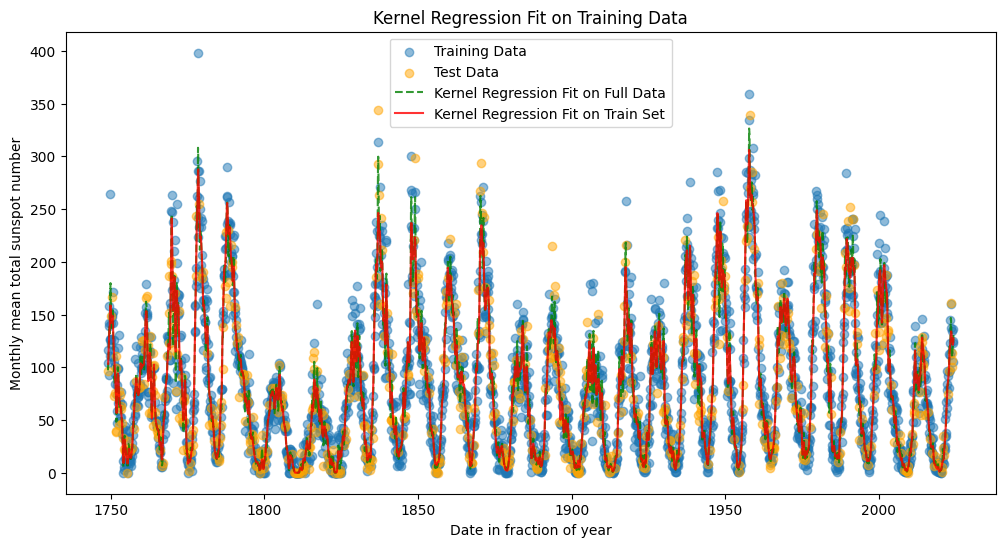

In [41]:
plt.figure(figsize=(12, 6))
plt.scatter(x_train, y_train, alpha=0.5, label='Training Data')
plt.scatter(x_test, y_test, alpha=0.5, label='Test Data', color='orange')
plt.plot(x,mean, color='green', alpha=0.8, label='Kernel Regression Fit on Full Data', linestyle='--')
plt.plot(train_fit['x_train'], train_fit['mean_train'], color='red', alpha=0.8, label='Kernel Regression Fit on Train Set')
# plt.plot(x,mean, color='green', alpha=0.8, label='Kernel Regression Fit on Full Data')
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Kernel Regression Fit on Training Data')
plt.legend()
plt.show()

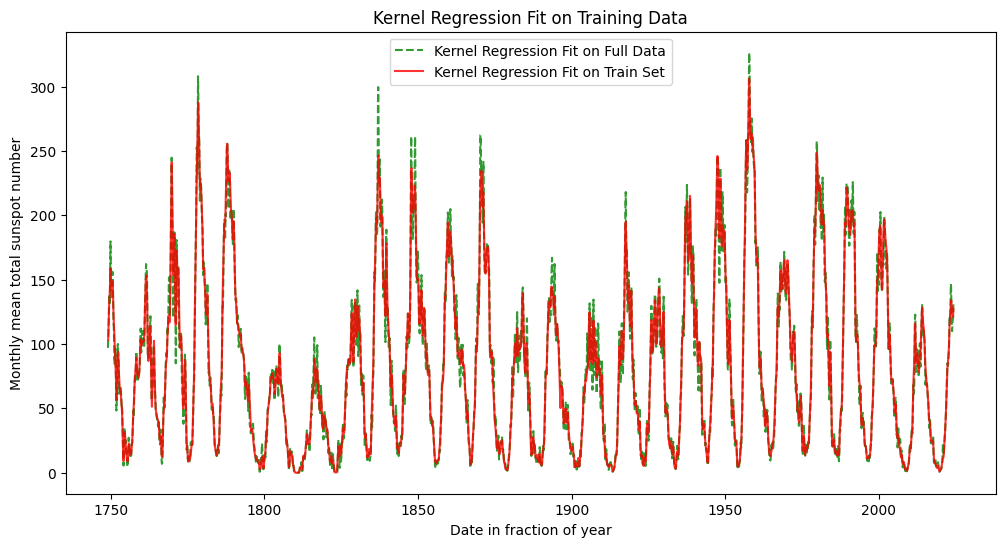

In [40]:
plt.figure(figsize=(12, 6))
# plt.scatter(x_train, y_train, alpha=0.5, label='Training Data')
# plt.scatter(x_test, y_test, alpha=0.5, label='Test Data', color='orange')
plt.plot(x,mean, color='green', alpha=0.8, label='Kernel Regression Fit on Full Data', linestyle='--')
plt.plot(train_fit['x_train'], train_fit['mean_train'], color='red', alpha=0.8, label='Kernel Regression Fit on Train Set', linestyle='-')
plt.xlabel('Date in fraction of year')
plt.ylabel('Monthly mean total sunspot number')
plt.title('Kernel Regression Fit on Training Data')
plt.legend()
plt.show()